# Espectro de un solo transmon
En este notebook encontramos comparamos diferencias en el espectro del transmon tomando distintas aproximaciones. El hamiltoniano del transmon es
$$
\hat H = 4E_c\hat n^2 - E_J \cos(\hat \delta)
$$
siendo $\hat n$ y $\hat \delta$ variables canónicamente conjugadas ($[\hat \delta, \hat n] = i$). En el régimen del transmon $E_J \gg E_c$ lo cual nos permite hacer una expansión en serie de potencias del coseno por lo cual, descartando términos constantes
$$
\hat  H \approx 4E_c\hat n^2 + \frac{E_J}{2}\hat \delta^2 - \frac{E_J}{24} \hat \delta^4  
$$
Definiendo 
$$
\hat \delta = \left(\frac{2E_C}{E_J}\right)^{1/4} (\hat b^\dag + \hat b),
$$
$$
\hat n = \frac{i}{2}\left(\frac{E_J}{2E_C}\right)^{1/4} (\hat b^\dag - \hat b)
$$
llegamos a la siguiente expresión
$$
\hat H \approx \hbar \omega_0 \hat b^\dag \hat b - \hbar \lambda(\hat b^\dag + \hat b)^4
$$
con $\hbar \omega_0 = \sqrt{8E_c E_J}$ y $\hbar \lambda = \frac{E_c}{12}$. Tras expandir el último término, este puede ser escrito como:
$$
(\hat b + \hat b^\dag)^4 = \hat O_4 + \hat O_2 + \hat O_0
$$
con $O_k$ la parte del operador que cambia al estado en $k$ excitaciones:
$$
\hat O_4 = \hat b^4 + (\hat b^{\dag})^4
$$
$$
\hat O_2 = 4\left((\hat b^\dag)^3 \hat b + \hat b^\dag \hat b^3\right) + 6\left(\hat b^2 + (\hat b^\dag)^2\right)
$$
$$
\hat O_0 = 6(\hat b^\dag)^2 \hat b^2 + 12\hat b^\dag \hat b
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import qutip as qt
from scipy.special import genlaguerre, gammaln
import scienceplots
plt.style.use(['science', 'notebook'])

In [ ]:
# expresion analitica para la matriz (en base de fock) del operador e^{i u (\hat a + \hat a^\dag)}
# def compute_position_exponential(N, u): 
#   matrix = np.zeros(shape= (N, N), dtype = complex)
#   for m in range(N):
#     for n in range(N):
#       if m >= n:
#         matrix[m][n] = np.exp(-u**2/2) * np.sqrt(factorial(n)/factorial(m)) * (1.0j*u)**(m-n)*genlaguerre(n, m-n)(u**2)
#       else:
#         matrix[m][n] = np.exp(-u**2/2) * np.sqrt(factorial(m)/factorial(n)) * (1.0j*u)**(n-m)*genlaguerre(m, n-m)(u**2)

#   return qt.Qobj(matrix)
def compute_position_exponential(N, u): 
  matrix = np.zeros(shape=(N, N), dtype=complex)
  for m in range(N):
    for n in range(N):
      if m >= n:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(n+1) - gammaln(m+1)))
          * (1.0j*u)**(m-n)
          * genlaguerre(n, m-n)(u**2)
        )
      else:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(m+1) - gammaln(n+1)))
          * (1.0j*u)**(n-m)
          * genlaguerre(m, n-m)(u**2)
        )

  return qt.Qobj(matrix)

# hamiltoniano exacto con dimensión truncada en N estados de Fock
def exact_transmon_hamiltonian(N, E_c, E_j):
    charge_number = 0.5j * (E_j/(2*E_c))**0.25 * (qt.destroy(N).dag() - qt.destroy(N))
    phase_prefactor = (2 * E_c / E_j)**0.25
    cos_delta = 0.5 * (compute_position_exponential(N, phase_prefactor) + compute_position_exponential(N, -phase_prefactor))
    return 4 * E_c * charge_number**2 - E_j * cos_delta

# términos para el término de orden 4
def O_0(N):
  return 6 * qt.destroy(N).dag()**2 * qt.destroy(N)**2

def O_2(N):
  return 4 * (qt.destroy(N).dag()**3 * qt.destroy(N) + qt.destroy(N).dag() * qt.destroy(N)**3) + 6 * (qt.destroy(N)**2 + qt.destroy(N).dag()**2)

def O_4(N):
  return qt.destroy(N)**4 + qt.destroy(N).dag()**4

def quadratic_interacting(N):
  return 6 * qt.destroy(N).dag()**2 * qt.destroy(N)**2 + 6 * (qt.destroy(N)**2 + qt.destroy(N).dag()**2)

In [ ]:
EJ_values = np.linspace(30.0, 200.0)
E_c = 1.0
N_values = [2, 4, 8, 16]
energies = []

for i, N in enumerate(N_values):
    energy_matrix = np.zeros((len(EJ_values), N))
    
    for j, E_J in enumerate(EJ_values):
        exact_hamiltonian = exact_transmon_hamiltonian(N, E_c, E_J)
        E = exact_hamiltonian.eigenenergies()
        energy_matrix[j, :] = E
    
    energies.append(energy_matrix)

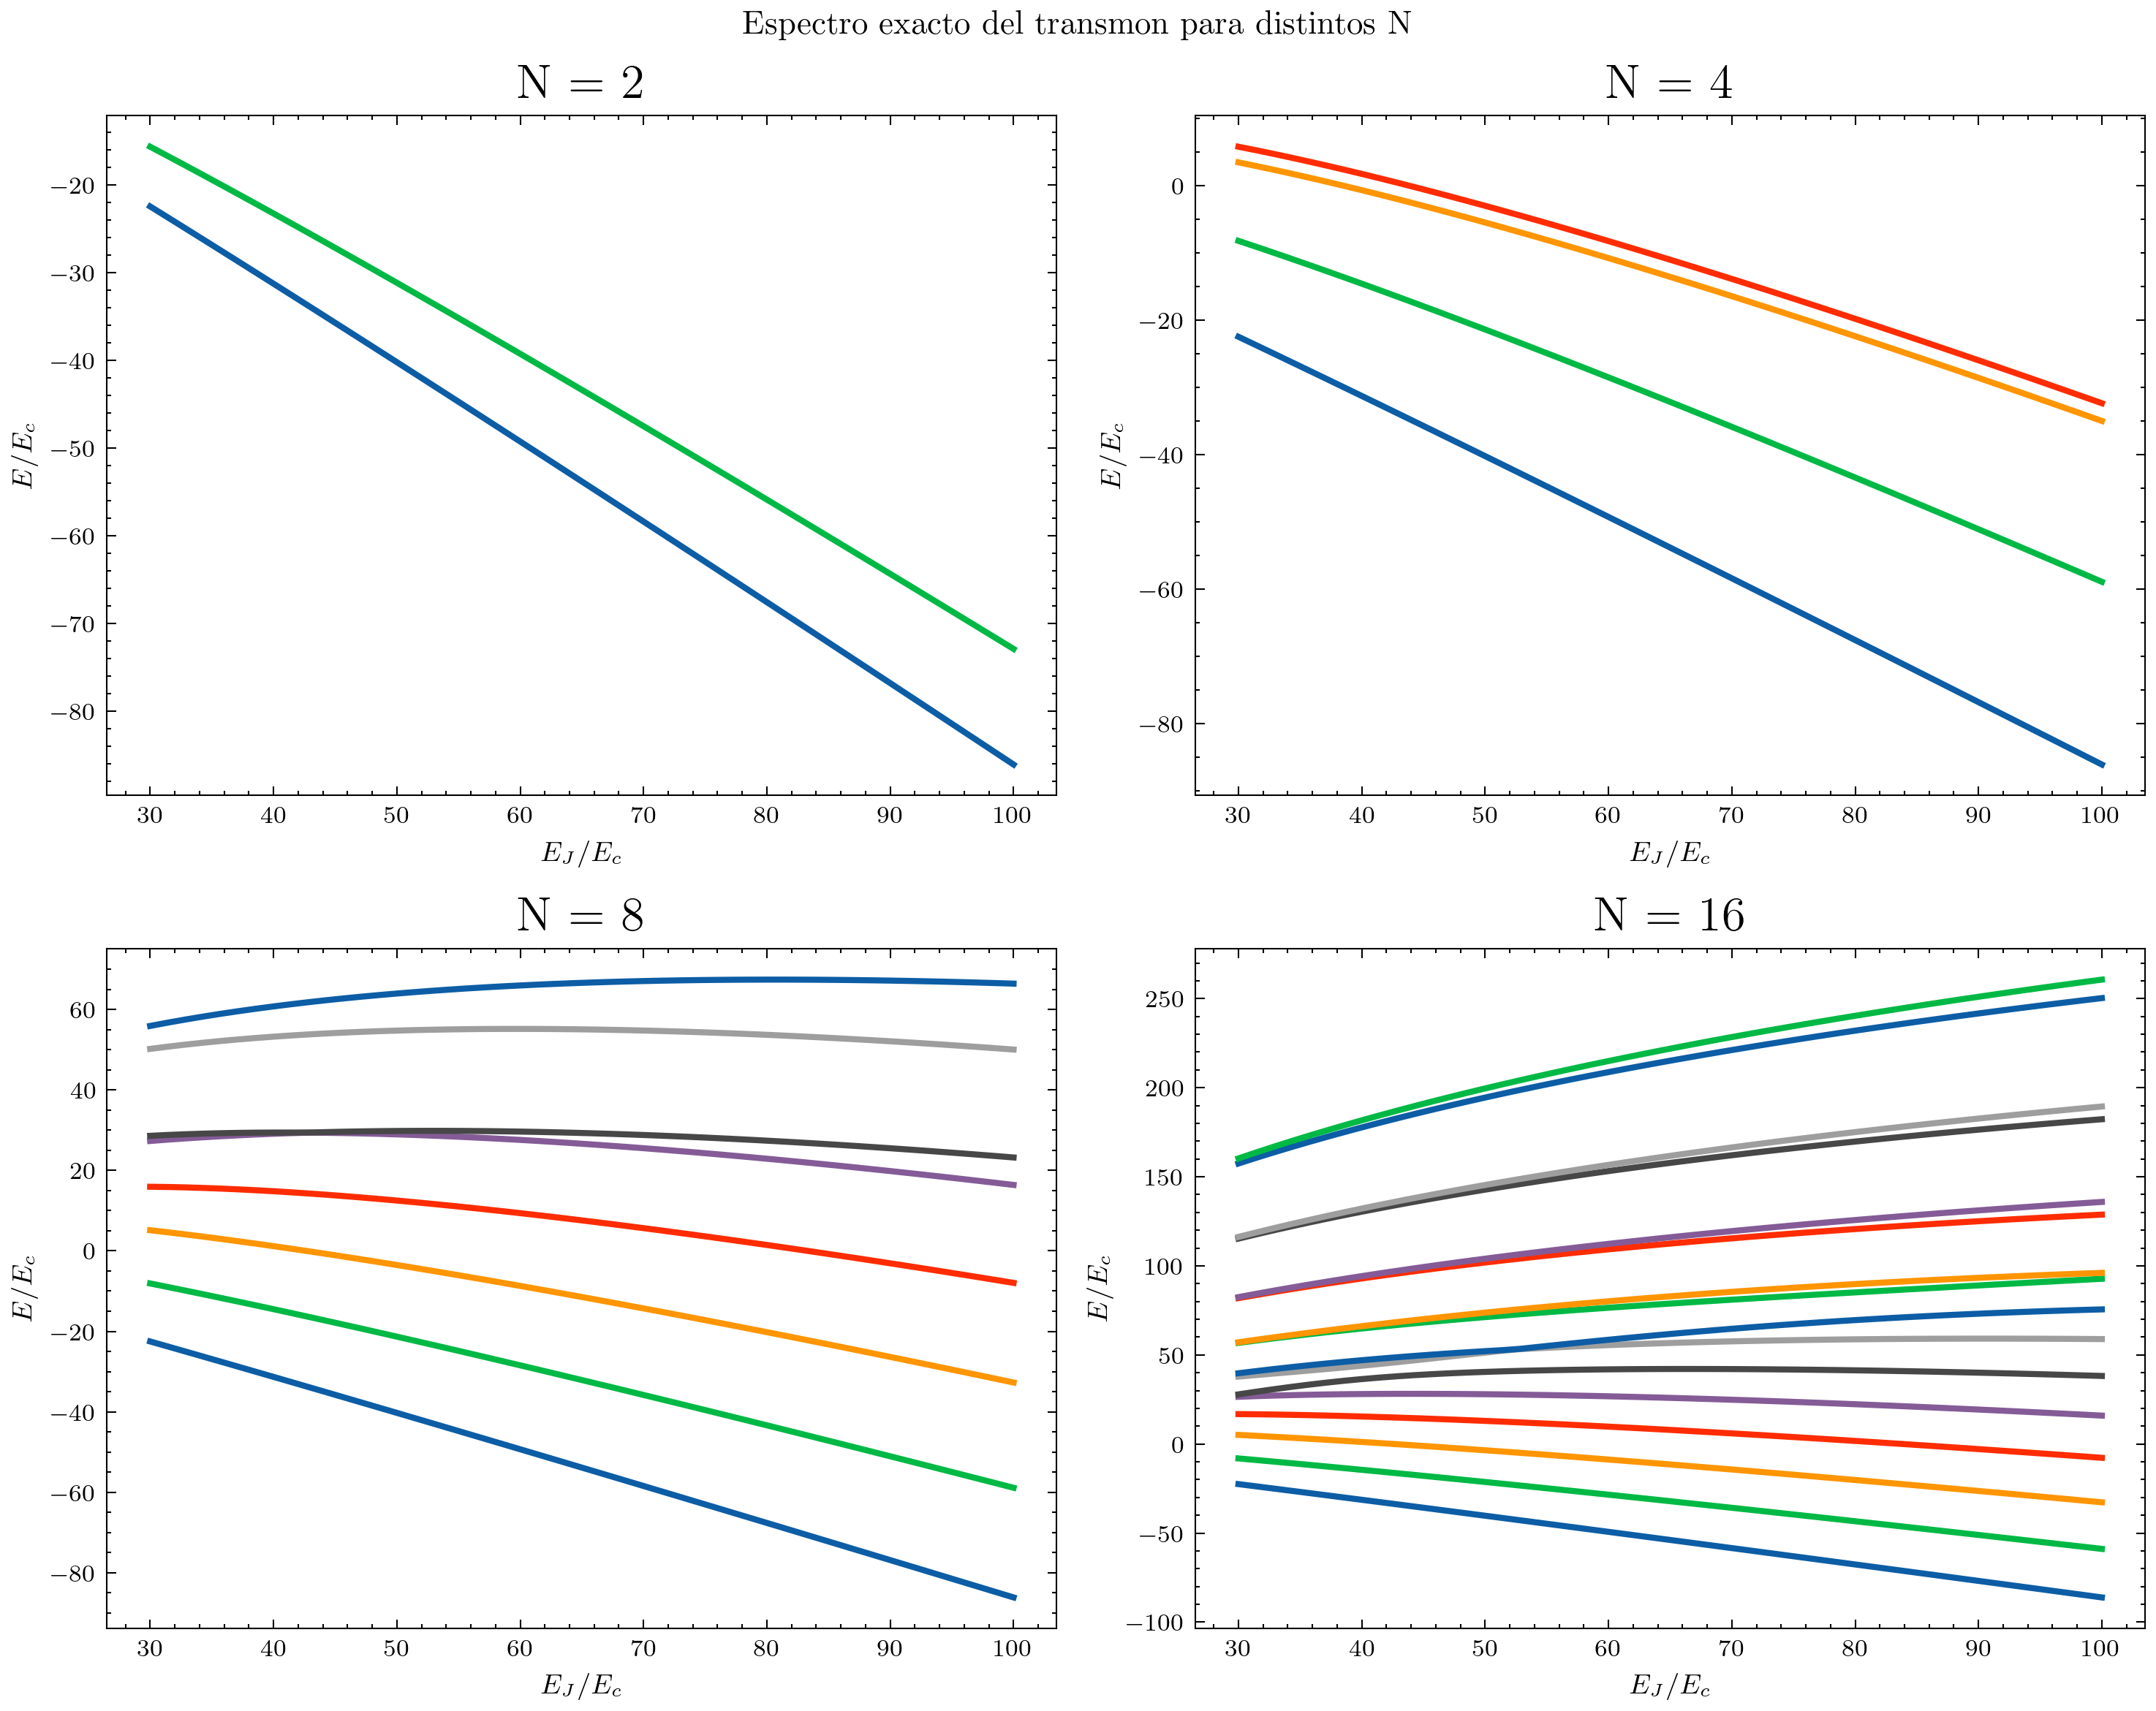

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle('Espectro exacto del transmon para distintos N')
# min_y = -40.0
# max_y = 20.0

for i, (n, ax, energy_matrix) in enumerate(zip(N_values, axes.flatten(), energies)):
    ax.set_title(f"N = {n}")
    ax.plot(EJ_values, energy_matrix) 
    ax.set_xlabel('$E_J/E_c$')
    ax.set_ylabel('$E/E_c$')
    # ax.set_ylim(min_y, max_y)
    
fig.tight_layout()
plt.show()

In [185]:
import numpy as np
import scipy.linalg

N_MAT =  1000 # matrix truncation for Mathieu, increase if needed

def mathieu_a_mat(r, q):
    n = N_MAT
    M = np.diag(np.square(2 * np.arange(n)).astype(float))
    M += np.diag(q * np.ones(n - 1), k=-1)
    M += np.diag(q * np.ones(n - 1), k=1)
    M[0, 1] *= np.sqrt(2)
    M[1, 0] *= np.sqrt(2)
    return scipy.linalg.eigvalsh(M, subset_by_index=[r-1, r-1])[0]

def mathieu_b_mat(r, q):
    # even b
    n = N_MAT
    if r % 2 == 0:
        M = np.diag(np.square(2 + 2 * np.arange(n)).astype(float))
        M += np.diag(q * np.ones(n - 1), k=-1)
        M += np.diag(q * np.ones(n - 1), k=1)
        idx = r // 2 - 1
    else:
        M = np.diag(np.square(1 + 2 * np.arange(n)).astype(float))
        M += np.diag(q * np.ones(n - 1), k=-1)
        M += np.diag(q * np.ones(n - 1), k=1)
        M[0, 0] -= q
        idx = r // 2
    return scipy.linalg.eigvalsh(M, subset_by_index=[idx, idx])[0]



In [189]:
from scipy.special import mathieu_a, mathieu_b

def transmon_spectrum(N, E_C, E_J):
    q = -E_J / (2 * E_C)
    energies = []
    for m in range(N):
        r = m // 2 + 1
        if m % 2 == 0:
            energies.append(E_C * mathieu_a(r, q))
        else:
            energies.append(E_C * mathieu_b(r, q))
    return np.array(energies)

def transmon_spectrum_1(N, E_C, E_J):
    q = -E_J / (2 * E_C)
    energies = []
    for m in range(N):
        r = m // 2 + 1        # same indexing as scipy version
        if m % 2 == 0:
            energies.append(E_C * mathieu_a_mat(r, q))
        else:
            energies.append(E_C * mathieu_b_mat(r, q))
    return np.array(energies)

n_energies = 14
EJ_values = np.linspace(30.0, 200.0)
energy_array = np.array([
    transmon_spectrum(n_energies, E_c, ej)
    for ej in EJ_values
])
energy_array_1 = np.array([
    transmon_spectrum_1(n_energies, E_c, ej)
    for ej in EJ_values
])

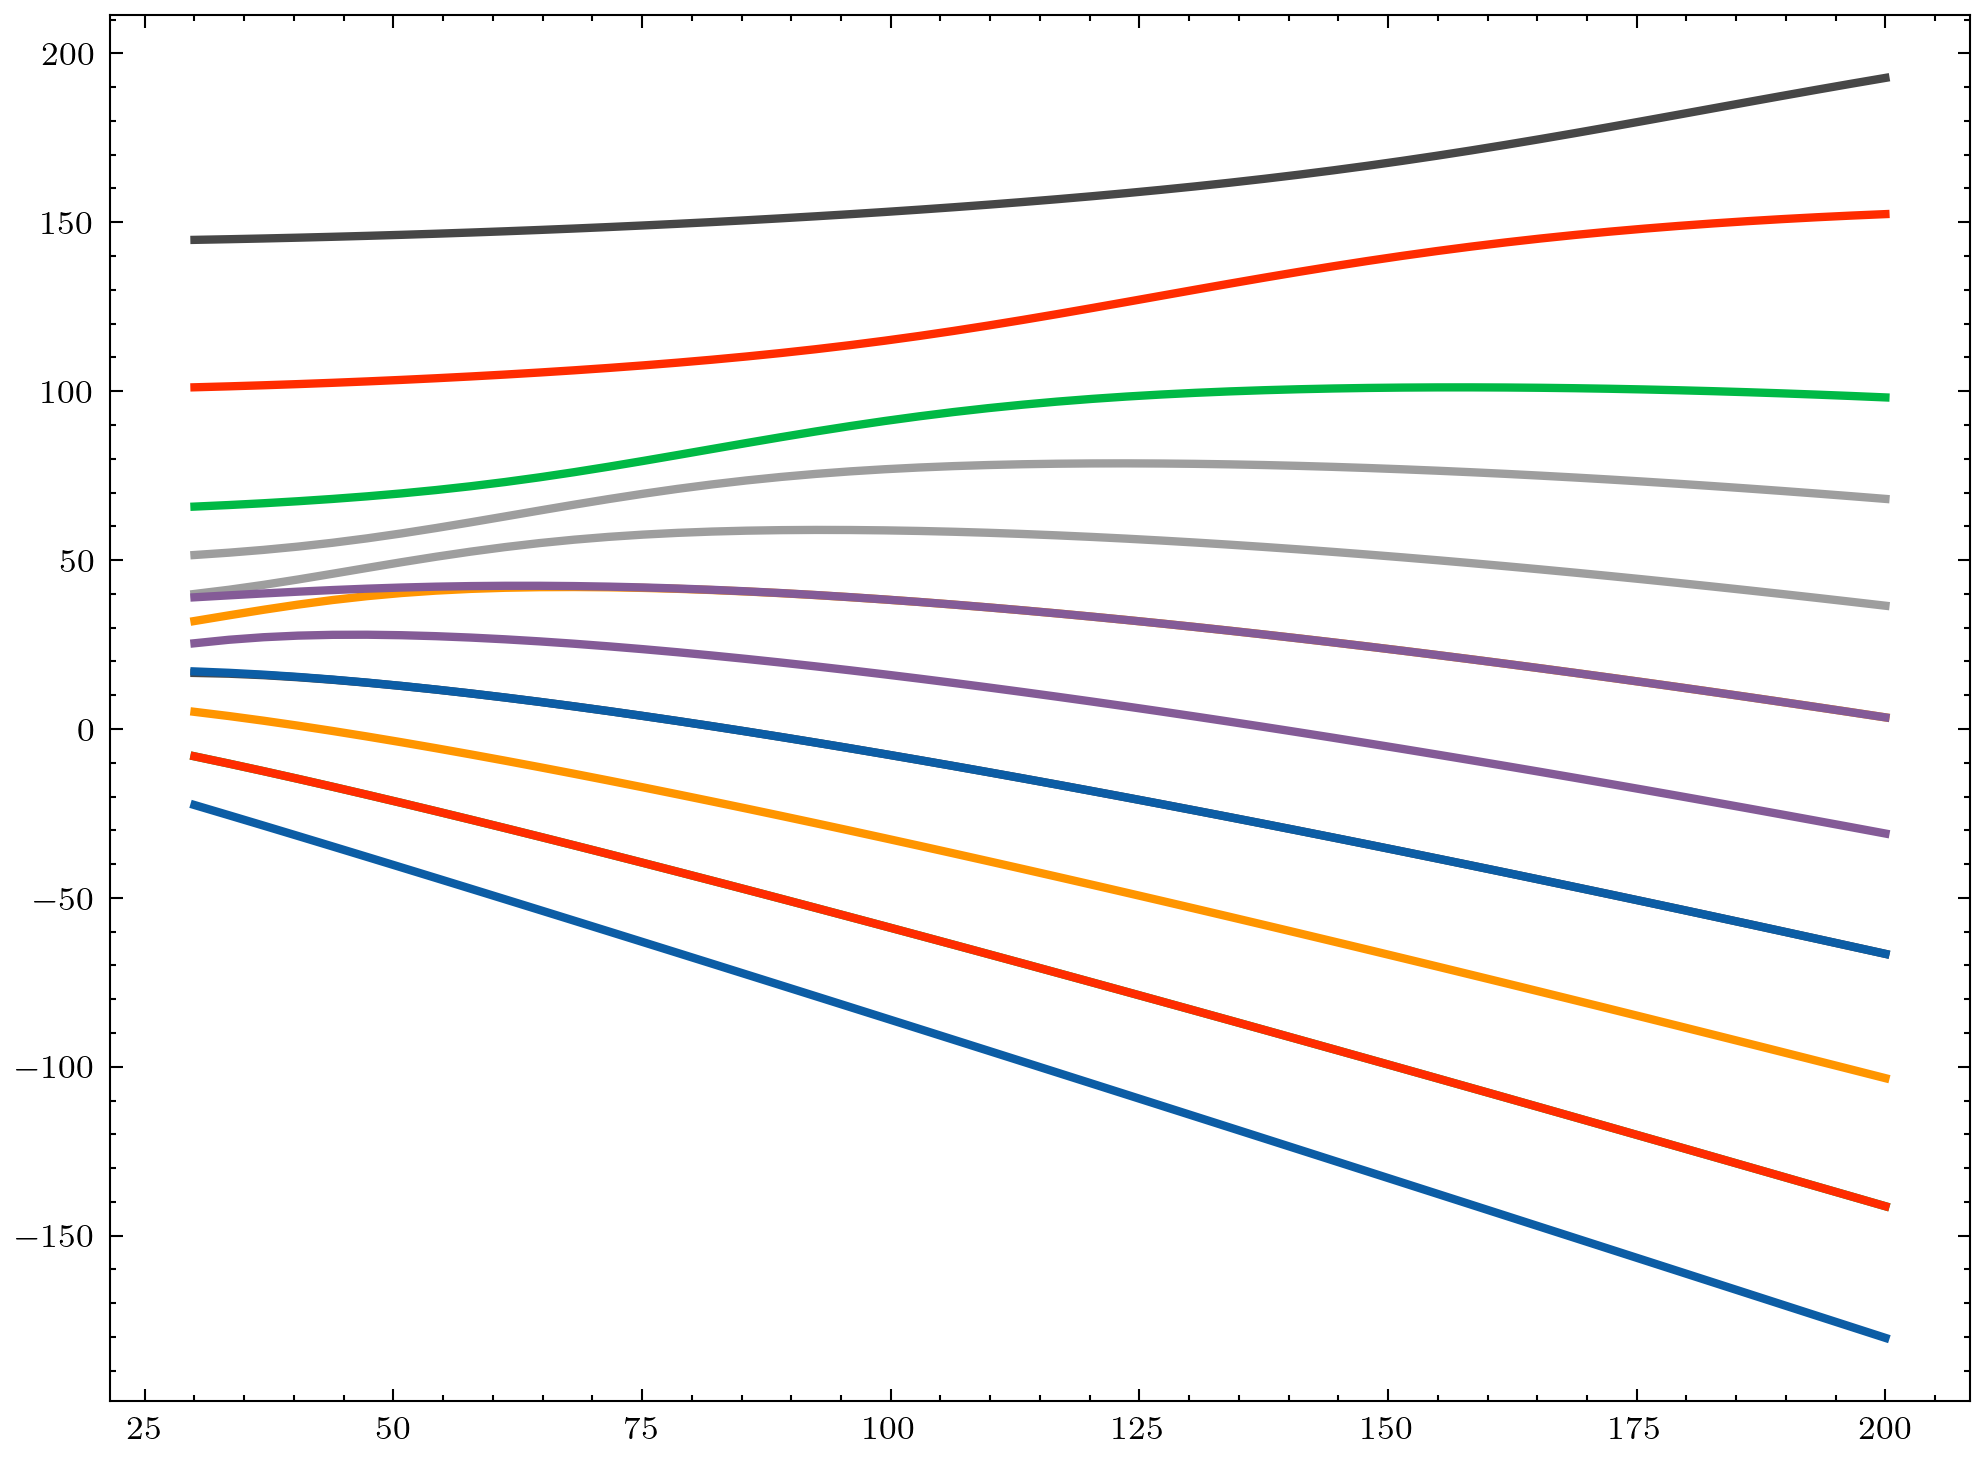

In [190]:
plt.plot(EJ_values, energy_array_1)

In [208]:
energy_array_1.shape

(50, 14)

In [209]:
energy_array_1 = np.sort(energy_array_1, axis = 1)

In [239]:
ej_mask = EJ_values >= 50
EJ_masked = EJ_values[ej_mask]

In [261]:

np.array(energies[1]).shape

(50, 4)

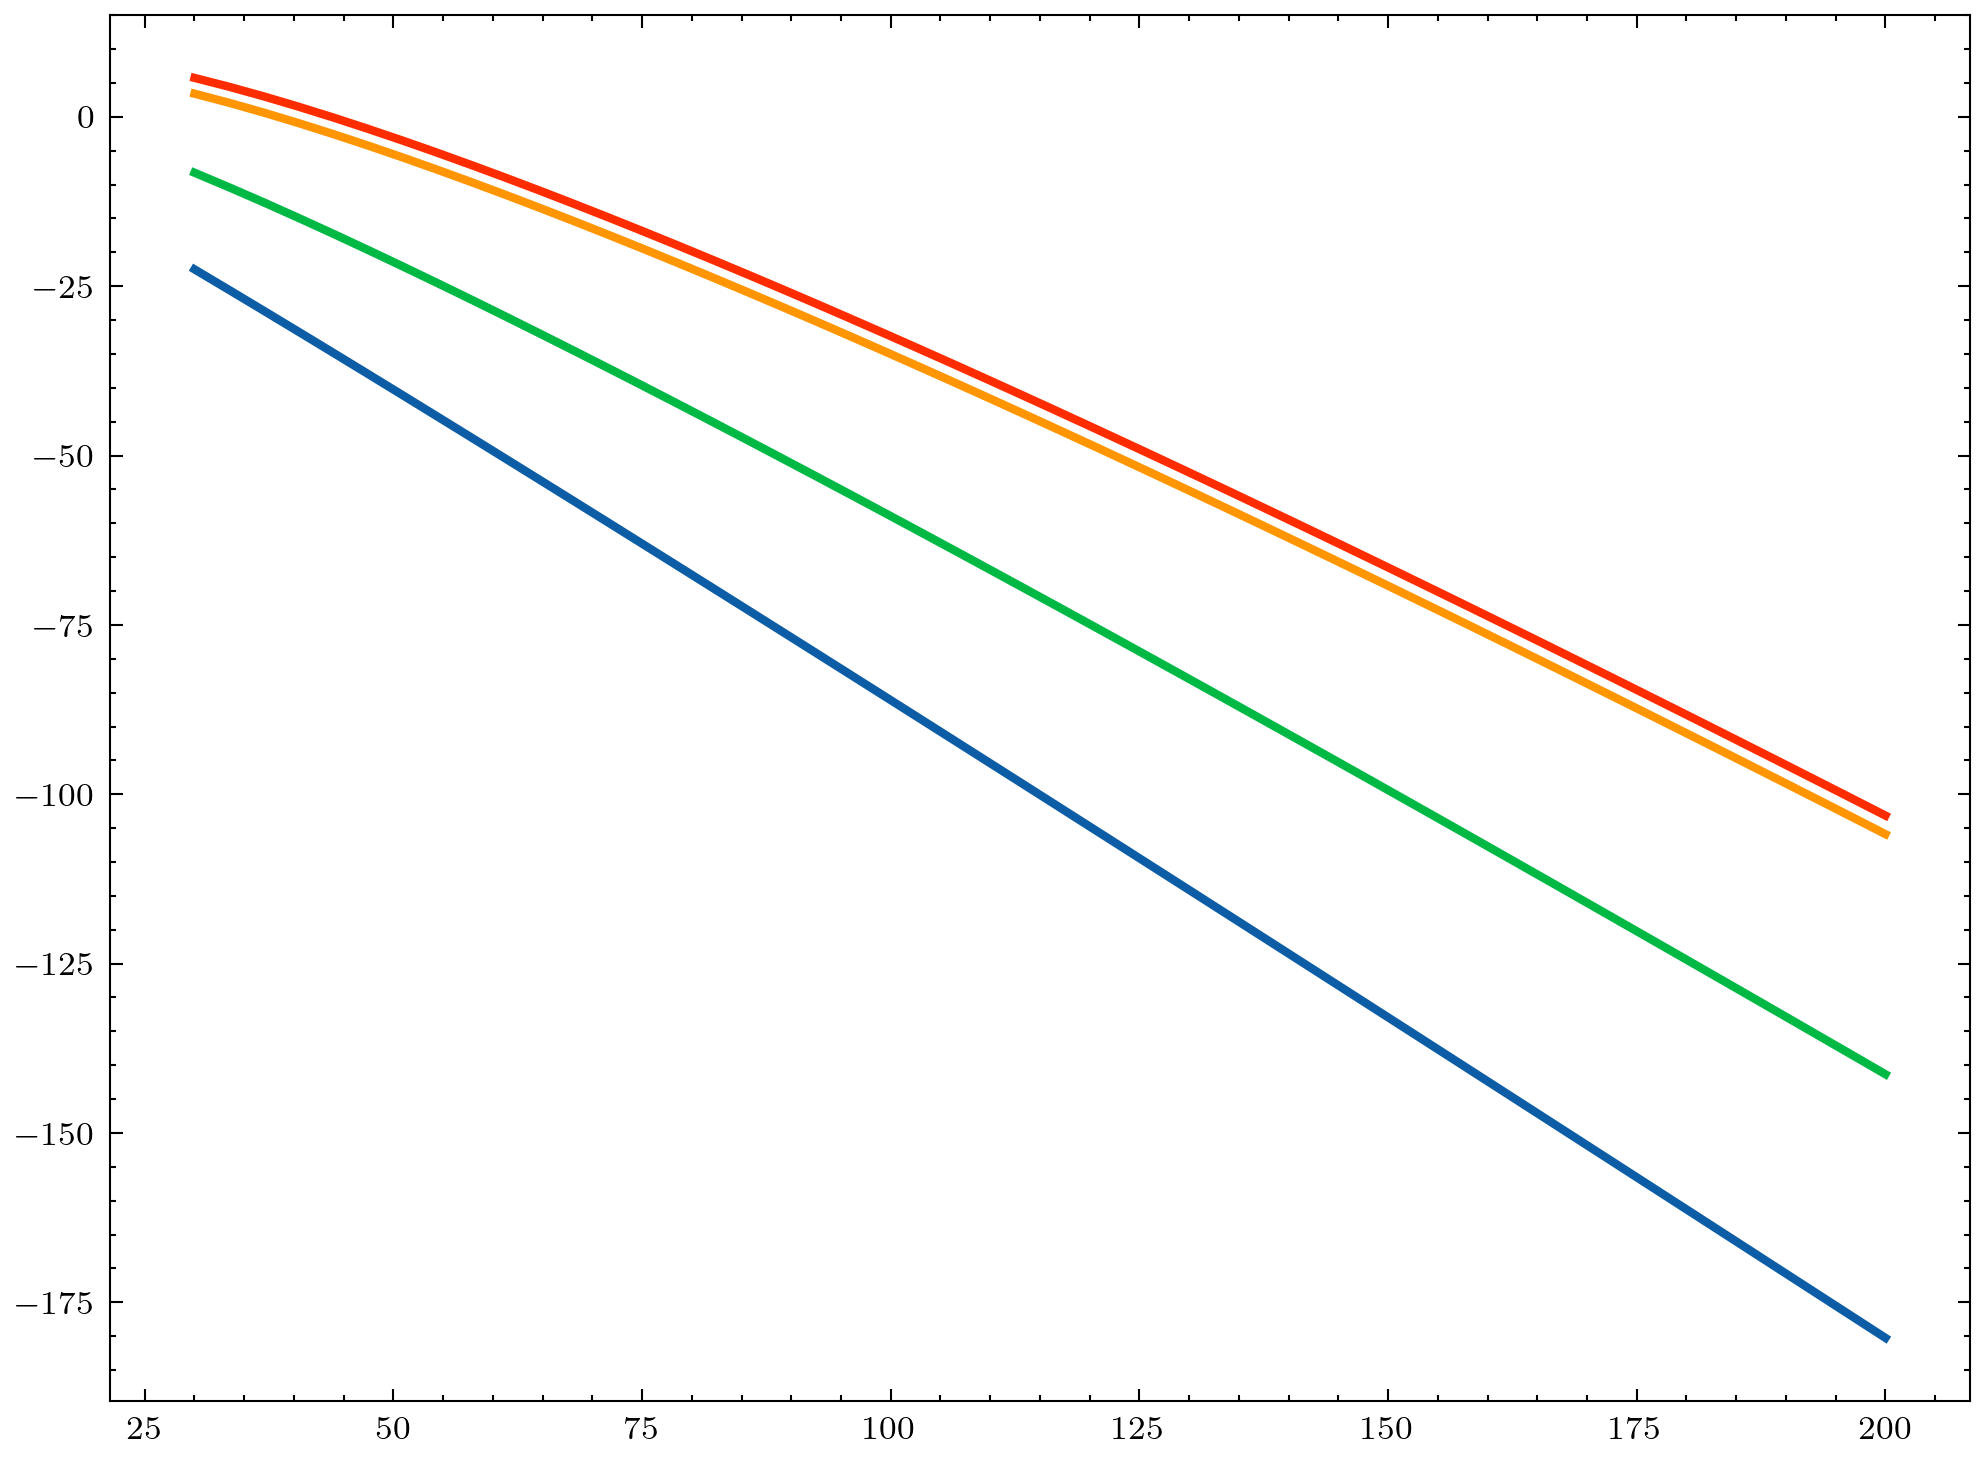

In [262]:
plt.plot(EJ_values, energies[1])

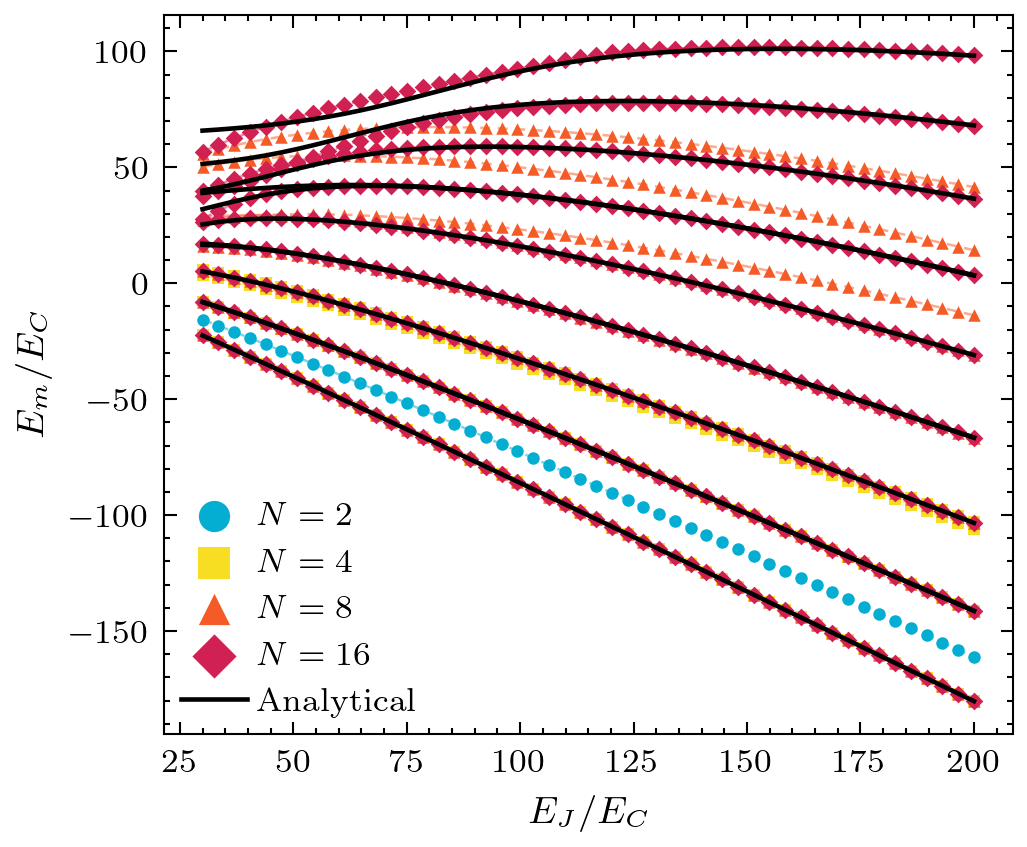

In [267]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'text.usetex':       True,
    'font.size':         9,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'axes.linewidth':    0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,  # fix: minor ticks same weight as major
    'ytick.minor.width': 0.5,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  1.5,
    'ytick.minor.size':  1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'figure.dpi':        300,
})

colors  = ['#03AED2', '#F8DE22', '#F45B26', '#D12052']
markers = ['o', 's', '^', 'D']
ms      = 9
max_bands1 = 9
max_bands2 = 12
fig, ax = plt.subplots(figsize=(3.4, 2.8))

for i, (n, color, marker, energy_matrix) in enumerate(
        zip(N_values, colors, markers, energies)):
    for level_idx, energy_level in enumerate(energy_matrix.T[:max_bands1]):
        ax.scatter(EJ_values, energy_level,
                   color=color, marker=marker, s=ms,
                   label=f'$N={n}$' if level_idx == 0 else None,
                   zorder=3, linewidths=0)

# dashed lines through the scatter points, one per level per N
for i, (color, energy_matrix) in enumerate(zip(colors, energies)):
    for energy_level in energy_matrix.T[:max_bands1]:
        ax.plot(EJ_values, energy_level,
                color=color, linewidth=0.6,
                linestyle='--', dashes=(4, 3),
                alpha=0.5, zorder=2)

# Mathieu reference lines
for j, band in enumerate(energy_array_1.T[:max_bands2]):
    if j == 0:
        ax.plot(EJ_values, band, color='black', linewidth=1.1, zorder=4, label = 'Analytical')
    else:
        ax.plot(EJ_values, band, color='black', linewidth=1.1, zorder=4, label = '')

ax.set_xlabel(r'$E_J/E_C$')
ax.set_ylabel(r'$E_m/E_C$')
# ax.set_ylim(-200.0, 150.0)
# ax.set_xlim(left = 45)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, handletextpad=0.3, borderpad=0, markerscale = 2.5)

fig.tight_layout(pad=0.3)
fig.savefig('../../../figures/export/single_transmon_truncation_final.pdf', bbox_inches='tight', dpi = 600)
plt.show()

In [105]:
len(energy_array_1.T)

10

# Conclusiones del truncamiento? 
Pareciera que en general el error de truncamiento disminuye conforme nos entramos más al régimen transmon ($\frac{E_J}{E_C} \rightarrow \infty$). $N = 2$ es pésimo, no lo usaremos en una primera instancia, $N = 5$ deja de servir a partir del 3er nivel de energía. Por último, si nos fijamos en los primeros 4 niveles de energía, $N= 10$ y $N = 20$ son muy parecidos para $\frac{E_J}{E_C} \gtrsim 30$ mientras que para valores menores difieren bastante cualitativamente.

**En adelante consideraremos como referencia $E_J / E_c \gtrsim 40.0$ y usaremos $N = 8$**. (No probé mayores valores de N por que calculo factoriales y la precisión numérica se va al ...)

# Comparación diagonalización exacta con aproximación

In [223]:
# EJ_values = np.linspace(30.0, 70.0)
E_c = 1.0
lamb = E_c / 12.0
N = 16
# calculamos energias con el hamiltoniano exacto y con los obtenidos por los distintos ordenes de la expansion de Taylor
exact_energies = []
harmonic_energies = []
kerr_energies = []
pairing_energies = []
for j, E_J in enumerate(EJ_values):
    hbar_omega_0 = np.sqrt(8 * E_c * E_J) - E_c
    hamiltonian_0 = hbar_omega_0 * qt.num(N)
    hamiltonian_1 = hbar_omega_0 * qt.num(N) - lamb * O_0(N)
    hamiltonian_2 = hamiltonian_0 - lamb * quadratic_interacting(N)
    exact_hamiltonian = exact_transmon_hamiltonian(N, E_c, E_J)
    exact_energies.append(np.array(exact_hamiltonian.eigenenergies()))
    harmonic_energies.append(np.array(hamiltonian_0.eigenenergies()))
    kerr_energies.append(np.array(hamiltonian_2.eigenenergies()))
    pairing_energies.append(np.array(hamiltonian_1.eigenenergies()))
    
exact_energies = np.array(exact_energies)
harmonic_energies = np.array(harmonic_energies)
kerr_energies = np.array(kerr_energies)
pairing_energies = np.array(pairing_energies)

In [227]:
n_plot = 15  # number of levels to compare, adjust as needed

exact_differences   = (energy_array_1 - energy_array_1[:, [0]])[:, :n_plot]
zeroth_differences  = (harmonic_energies - harmonic_energies[:, [0]])[:, :n_plot]
second_differences  = (kerr_energies - kerr_energies[:, [0]])[:, :n_plot]
fourth_differences  = (pairing_energies - pairing_energies[:, [0]])[:, :n_plot]

differences_matrix = np.array([zeroth_differences, second_differences,
                                fourth_differences])

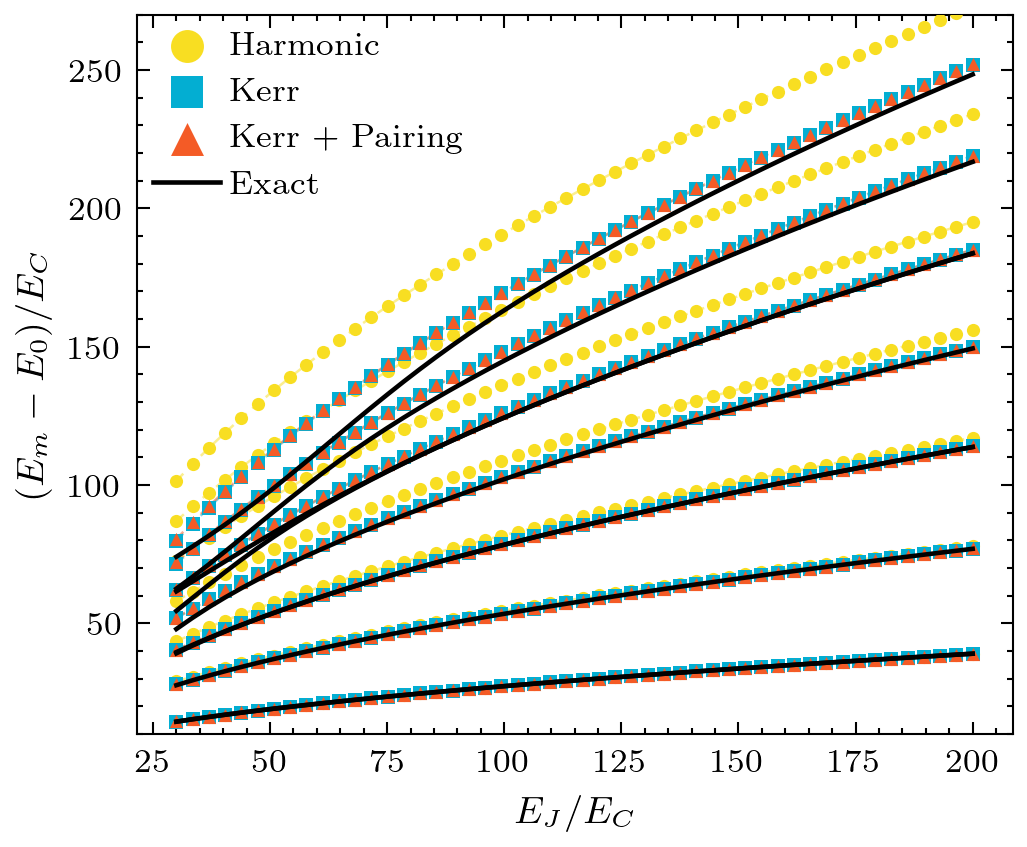

In [268]:
colors  = ['#F8DE22', '#03AED2', '#F45B26']
markers = ['o', 's', '^']
labels  = ['Harmonic', 'Kerr', 'Kerr + Pairing']
ms      = 10
max_band = 8
max_bands = 11
fig, ax = plt.subplots(figsize=(3.4, 2.8))

for color, marker, lab, energy_matrix in zip(colors, markers, labels, differences_matrix):
    for level_idx, energy_level in enumerate(energy_matrix.T[:max_band]):
        ax.scatter(EJ_values, energy_level,
                   color=color, marker=marker, s=ms,
                   label=lab if level_idx == 0 else None,
                   zorder=3, linewidths=0)

# dashed lines through scatter points
for color, energy_matrix in zip(colors, differences_matrix):
    for energy_level in energy_matrix.T[:max_band]:
        ax.plot(EJ_values, energy_level,
                color=color, linewidth=0.6,
                linestyle='--', dashes=(4, 3),
                alpha=0.5, zorder=2)

# exact reference as black line
for level_idx, energy_level in enumerate(exact_differences.T[:max_bands]):
    ax.plot(EJ_values, energy_level,
            color='black', linewidth=1.1, zorder=4,
            label='Exact' if level_idx == 0 else None)

ax.set_xlabel(r'$E_J/E_C$')
ax.set_ylabel(r'$(E_m - E_0)/E_C$')
ax.set_ylim(10.0, 270.0)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, handletextpad=0.3, borderpad=0, markerscale=2.5)

fig.tight_layout(pad=0.3)
fig.savefig('../../../figures/export/single_transmon_hamiltonian_comparison.pdf', bbox_inches='tight', dpi = 600)
plt.show()

Noté que conforme aumentaba la dimensión de truncamiento las aproximaciones se volvían peor y cambiaban demasiado cualitativamente, explicación: por alguna razón al aumentar N, se requiere un mayor orden en la expansión del coseno. Por otro lado, pareciera que está mejor utilizar solo hasta la expansión a términos de segundo orden, los términos de cuarto orden la empeoran.